# Simulation run from config file
This jupyter notebook aims to run a full configuration and show all the features regarding simulation. 

## Imports and generation

In [1]:
import os

from vote_simulation.simulation.simulation import simulation_series_from_config

print(os.getcwd())


results = simulation_series_from_config("config.toml", reload=True)

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/simulation


Running simulation series: 100%|██████████| 14/14 [02:50<00:00, 12.15s/it]

Completed 14 simulation series.


## Metrics

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_1D      1000             3        1000          1000       2.545238              AP_T05                STAR               8.600000
EUCLID_1D      1000             4        1000          1000       3.169048              AP_T05                STAR              10.750000
EUCLID_1D      1000             5        1000          1000       3.326190              AP_T05                STAR              11.250000
EUCLID_1D      1000             7        1000          1000       3.783333              AP_T05                SCHU              12.800000
EUCLID_1D      1000             9        1000          1000       4.054762              AP_T05                SCHU              13.816667
EUCLID_1D      1000            14        1000          1000       5.928571              AP_T05                BLAC              20.166666
EUCLID_2D      1000             3 

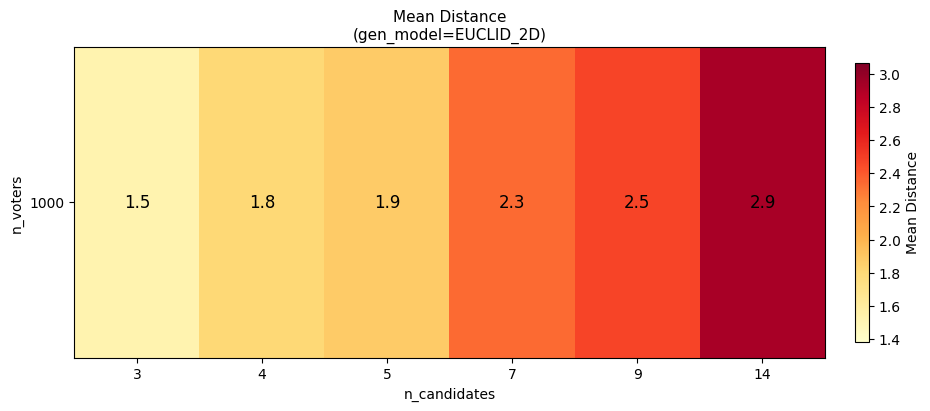

<Axes: title={'center': 'Mean Distance\n(gen_model=EUCLID_2D)'}, xlabel='n_candidates', ylabel='n_voters'>

In [13]:
df = results.summary_frame()
print(df.to_string(index=False))

results.filter(gen_model="EUCLID_2D").metric_matrix()

results.filter(gen_model="EUCLID_2D").plot_metric_heatmap(col_param="n_candidates", row_param="n_voters", show=True)

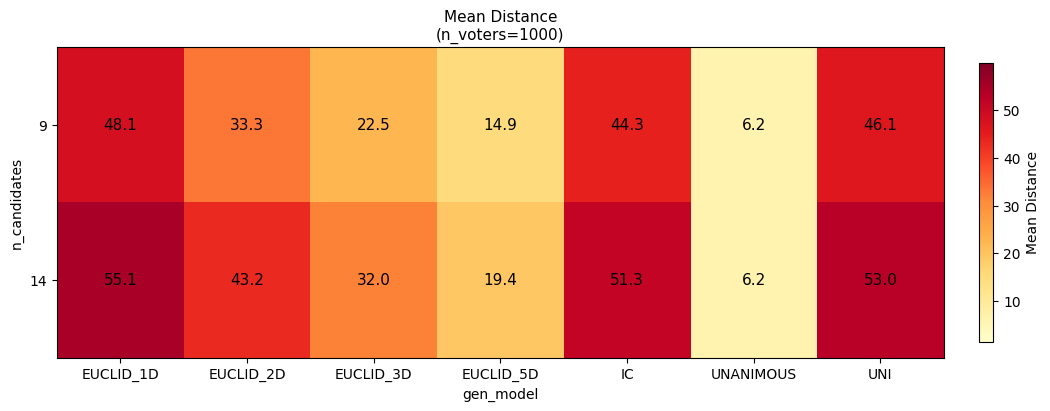

<Axes: title={'center': 'Mean Distance\n(n_voters=1000)'}, xlabel='gen_model', ylabel='n_candidates'>

In [2]:
# Impact of generation model

results.plot_metric_heatmap(col_param="gen_model", row_param="n_candidates", show=True)

## Filtering
As we discussed the model has to be able to "filter" to allow the study of the impact of one parameter

### Filter on number of candidates

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_1D      1000            14        1000          1000      55.090833              BUCK_R                BORD              97.849998
EUCLID_2D      1000            14        1000          1000      43.185832                BORD                PLU1              92.099998
EUCLID_3D      1000            14        1000          1000      32.040279                BORD                PLU1              82.300003
EUCLID_5D      1000            14        1000          1000      19.416528                BORD                PLU1              58.450001
       IC      1000            14        1000          1000      51.277913                  MJ                PLU1              84.199997
UNANIMOUS      1000            14        1000          1000       6.250000                  RV                AP_K              50.000000
      UNI      1000            14 

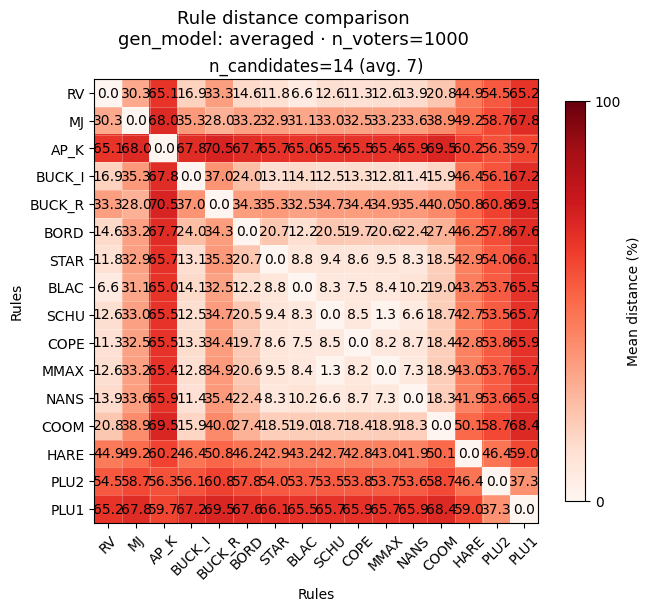

[<Axes: title={'center': 'n_candidates=14 (avg. 7)'}, xlabel='Rules', ylabel='Rules'>]

In [4]:
results_c14 = results.filter(n_candidates=14)
df_c14 = results_c14.summary_frame()
print(df_c14.to_string(index=False))

results.filter(n_candidates=14).plot_comparison_grid(show=True)

## Details of a serie 

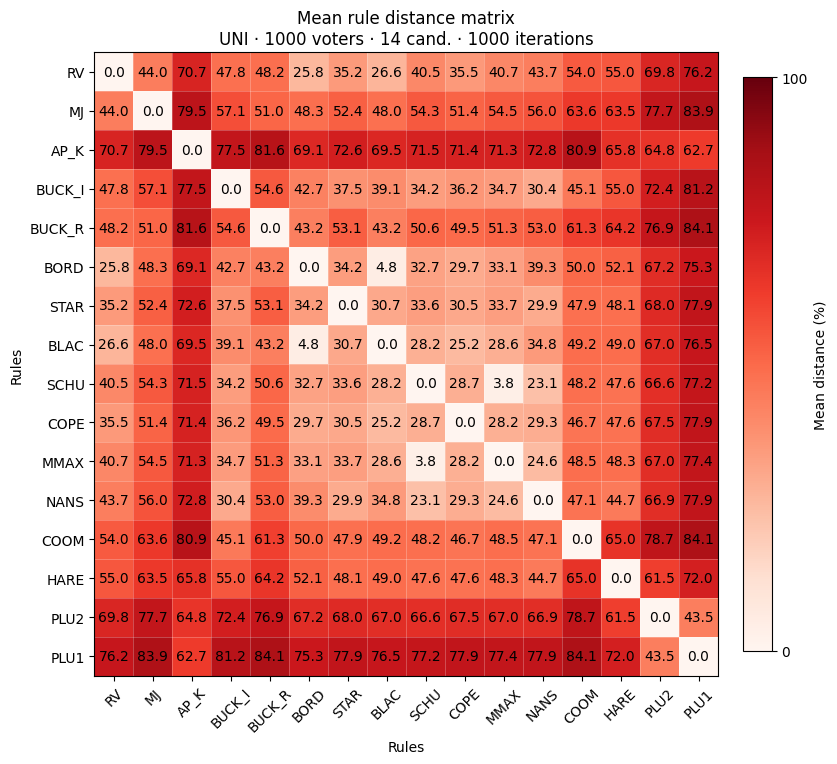

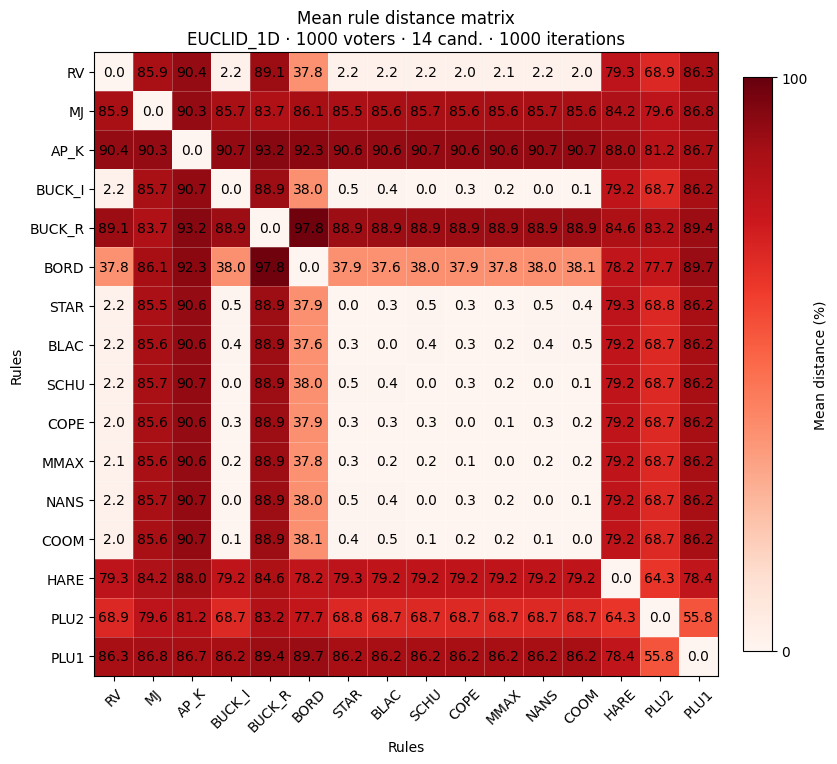

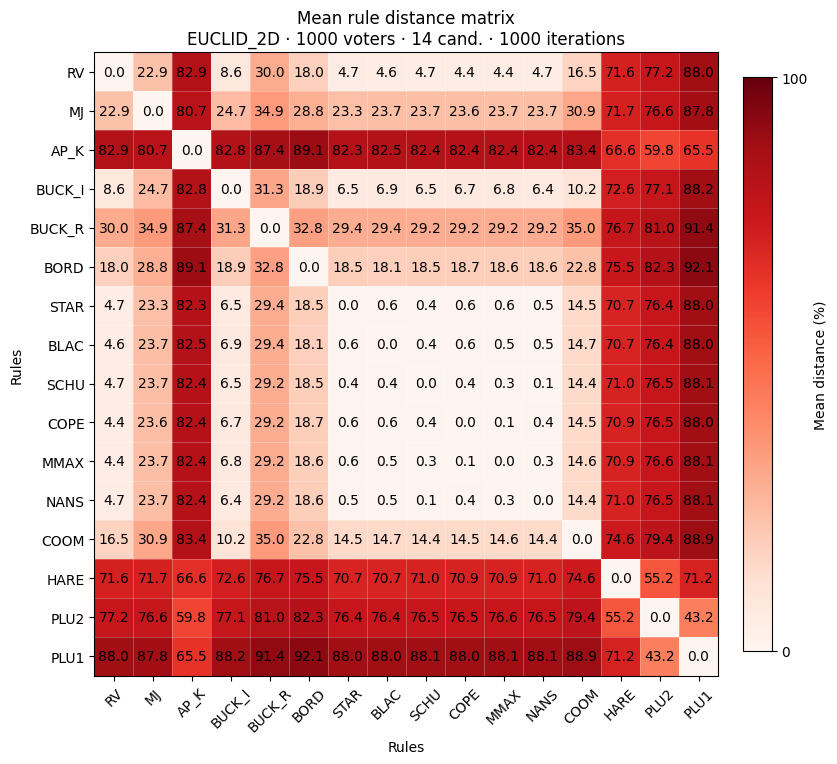

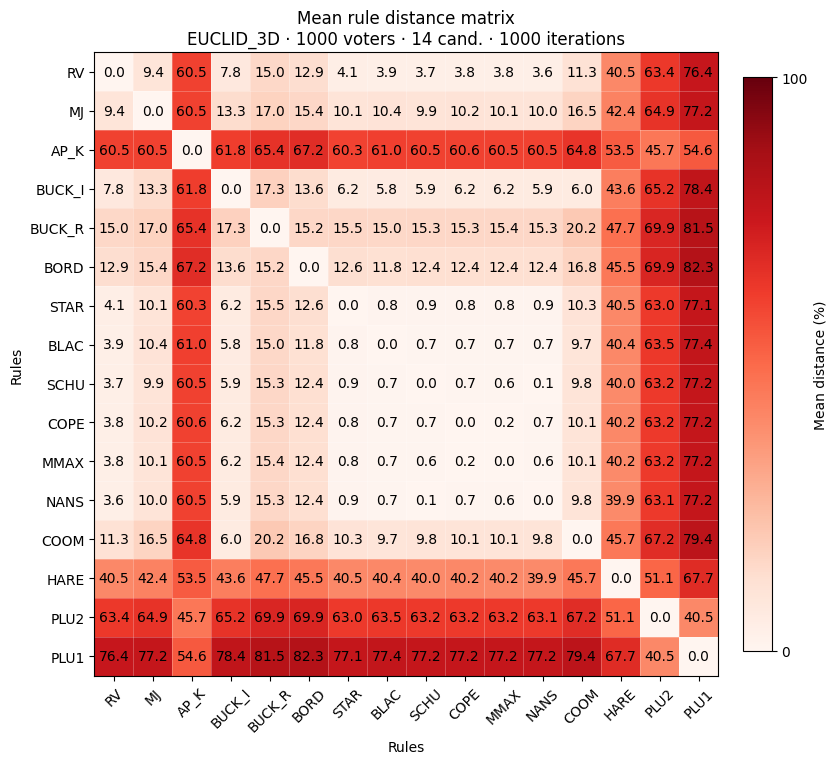

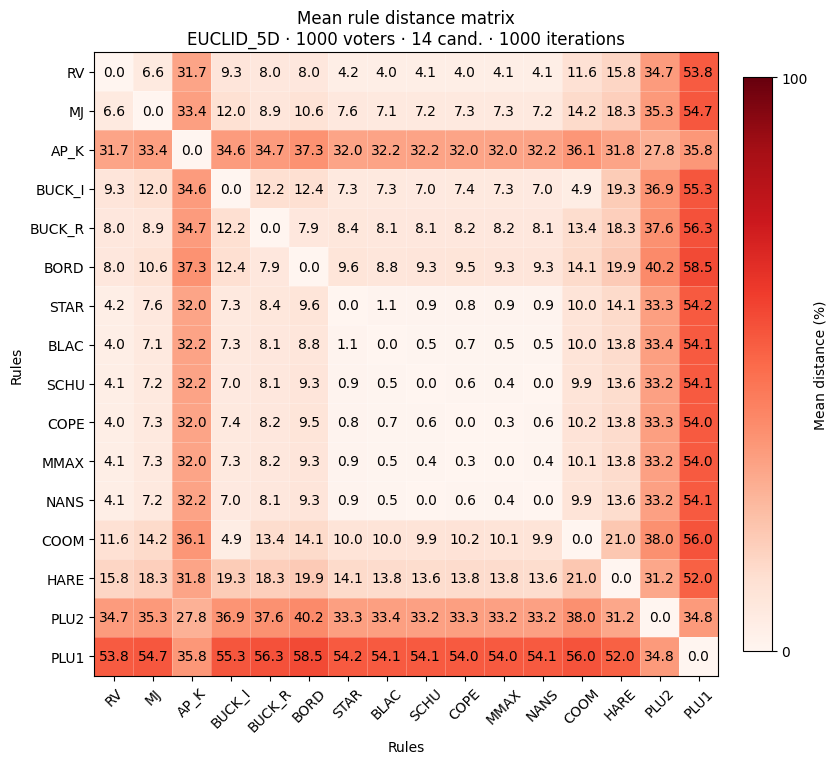

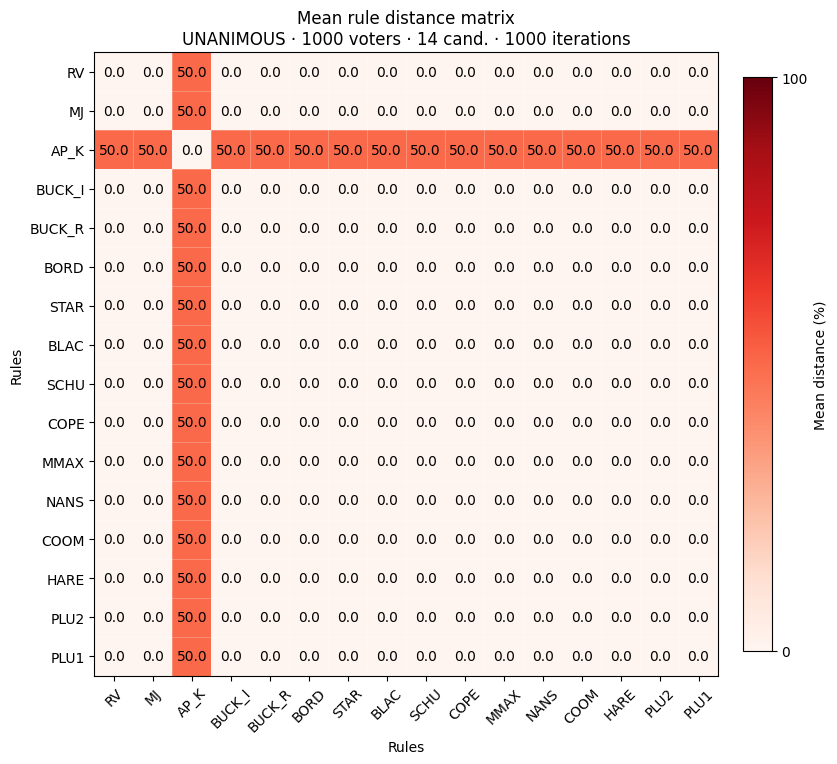

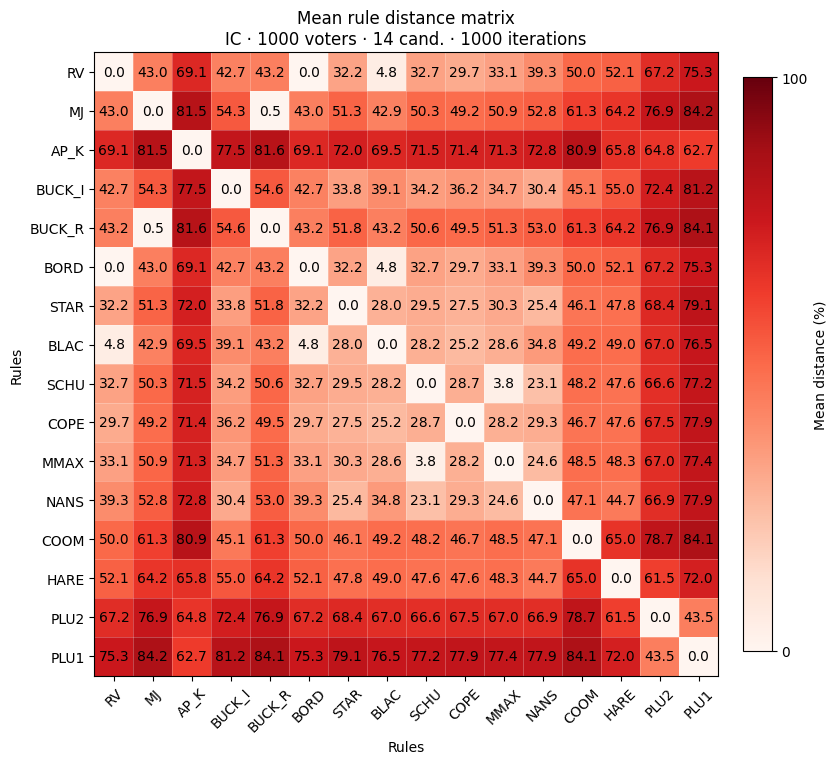

<Axes: title={'center': 'Mean rule distance matrix\nIC · 1000 voters · 14 cand. · 1000 iterations'}, xlabel='Rules', ylabel='Rules'>

In [5]:
# series = results.get_series("UNI",900, 14)
series = results.get_series("UNI", 1000, 14)


series.plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_1D", 1000, 14).plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_2D", 1000, 14).plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_3D", 1000, 14).plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_5D", 1000, 14).plot_mean_distance_matrix(show=True)

results.get_series("UNANIMOUS", 1000, 14).plot_mean_distance_matrix(show=True)

results.get_series("IC", 1000, 14).plot_mean_distance_matrix(show=True)

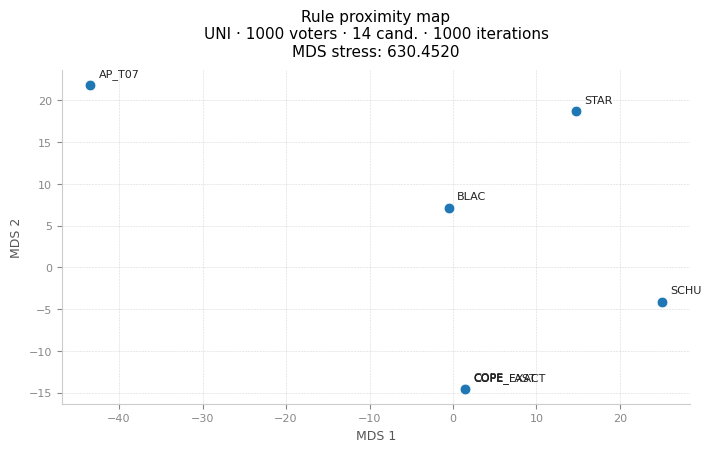

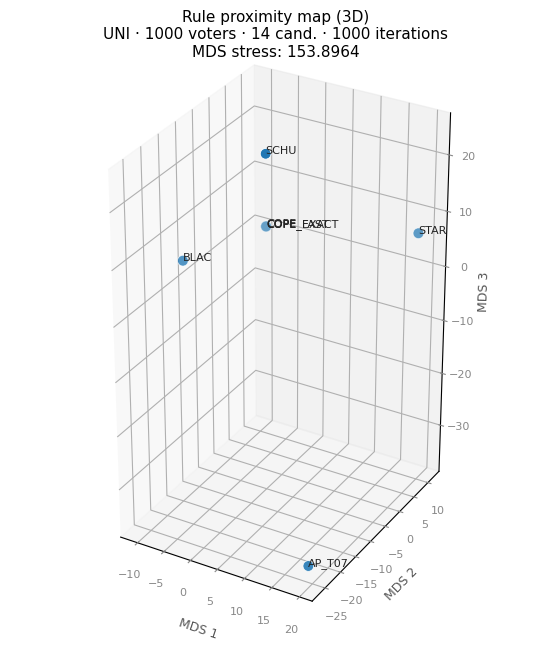

<Axes3D: title={'center': 'Rule proximity map (3D)\nUNI · 1000 voters · 14 cand. · 1000 iterations\nMDS stress: 153.8964'}, xlabel='MDS 1', ylabel='MDS 2', zlabel='MDS 3'>

In [18]:
series.plot_rules_2d(show=True)
series.plot_rules_3d(show=True)

# Metrics

In [11]:
results.filter(gen_model="IC").metric_matrix()

(n_candidates         3          4          5          7          9         14
 n_voters                                                                     
 1000          10.019047  14.883333  18.811906  23.137381  25.808332  29.62135,
 'gen_model=IC')